# 04: Final results 

The training notebook taught the models. The evaluation notebook measured them. This notebook has the role of interpreting the results and perform a scientific analysis of the results.

The notebook does not search for a new threshold on the test set and does not retrain the networks. It reads the files already produced by evaluation and answers five questions:

1. Can the models rank the **currently active nodes that will fail next**?
2. Do the GNN and hybrid model gain anything from explicitly seeing the graph?
3. Are the conclusions stable across unseen graph families and cascade mechanisms?
4. Can the models also estimate final cascade size and next-step load?
5. What can we honestly claim from a synthetic, graph-disjoint test?

Every important plot is followed by a detailed interpretation. The code also creates short, data-dependent explanations, so the text updates when the experiment is rerun.

## Imports

The notebook mostly uses `pandas` to read tables and `matplotlib` to draw final figures. `sklearn.metrics` is used only to turn saved predictions into a precision–recall curve or a confusion matrix. No model is fitted here.

In [35]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from IPython.display import Markdown, display
from sklearn.metrics import confusion_matrix, precision_recall_curve


## Saved evaluation files path

The folder layout is the same as in the previous notebooks. The results notebook writes polished figures to a separate folder, so the raw evaluation figures remain untouched.

In [36]:
current_folder = Path.cwd().resolve()

if (current_folder / "config.yaml").exists():
    ROOT = current_folder
elif (current_folder / "DL_project" / "config.yaml").exists():
    ROOT = current_folder / "DL_project"
elif (current_folder.parent / "config.yaml").exists():
    ROOT = current_folder.parent
else:
    raise FileNotFoundError(
        "config.yaml was not found. Run this notebook from the DL_project folder."
    )

with (ROOT / "config.yaml").open("r", encoding="utf-8") as file:
    config = yaml.safe_load(file)

DATA_DIR = ROOT / config["data"]["output_dir"]
HISTORY_DIR = ROOT / "artifacts" / "histories"
EVALUATION_DIR = ROOT / "artifacts" / "evaluation"
PREDICTION_DIR = ROOT / "artifacts" / "predictions"
TABLE_DIR = ROOT / "artifacts" / "results" / "tables"
RESULTS_DIR = ROOT / "artifacts" / "results" / "exam"
FIGURE_DIR = RESULTS_DIR / "figures"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAMES = ["mlp", "gnn", "hybrid"]
MODEL_LABELS = {
    "mlp": "MLP",
    "gnn": "GNN",
    "hybrid": "Hybrid GNN–Transformer",
    "load_ratio": "Load-ratio rule",
    "failed_neighbor": "Failed-neighbour rule",
    "degree": "Degree rule",
    "empirical_rate": "Average-risk rule",
    "persistence": "Persistence rule",
}

print("Project root:", ROOT)
print("Final exam figures:", FIGURE_DIR)


Project root: /home/riccorte/CIRCLES/DL/DL_project
Final exam figures: /home/riccorte/CIRCLES/DL/DL_project/artifacts/results/exam/figures


The most important files are:

- `model_comparison.csv`: one row for every neural model and heuristic;
- `grouped_metrics.csv`: performance split by graph family and cascade regime;
- one JSON file per neural model, containing the selected validation threshold and uncertainty intervals;
- one compressed prediction file per neural model, containing the final test targets and scores.

A missing file usually means that `03_evaluation_exam.ipynb` has not been run after the latest training run.

In [37]:
def require_file(path: Path, message: str) -> Path:
    if not path.exists():
        raise FileNotFoundError(f"{message}\nMissing file: {path}")
    return path


comparison = pd.read_csv(
    require_file(
        TABLE_DIR / "model_comparison.csv",
        "Run 03_evaluation_exam.ipynb before this results notebook.",
    )
)

grouped = pd.read_csv(
    require_file(
        TABLE_DIR / "grouped_metrics.csv",
        "The grouped evaluation table was not found.",
    )
)

split_audit_path = TABLE_DIR / "test_split_audit.csv"
split_audit = pd.read_csv(split_audit_path) if split_audit_path.exists() else None

model_metrics = {}
model_predictions = {}
threshold_tables = {}
bootstrap_tables = {}

for model_name in MODEL_NAMES:
    metric_path = require_file(
        EVALUATION_DIR / f"{model_name}_metrics.json",
        f"Metrics for {model_name} were not found.",
    )
    model_metrics[model_name] = json.loads(metric_path.read_text(encoding="utf-8"))

    prediction_path = require_file(
        PREDICTION_DIR / f"{model_name}_test_predictions.npz",
        f"Saved test predictions for {model_name} were not found.",
    )
    with np.load(prediction_path) as saved:
        model_predictions[model_name] = {key: saved[key] for key in saved.files}

    threshold_tables[model_name] = pd.read_csv(
        require_file(
            TABLE_DIR / f"{model_name}_threshold_curve.csv",
            f"Threshold curve for {model_name} was not found.",
        )
    )

    bootstrap_path = TABLE_DIR / f"{model_name}_bootstrap.csv"
    if bootstrap_path.exists():
        bootstrap_tables[model_name] = pd.read_csv(bootstrap_path)

comparison["display_name"] = comparison["model"].map(MODEL_LABELS).fillna(
    comparison["model"]
)
comparison


,model,type,precision,recall,f1,pr_auc,roc_auc,graph_mae,load_mae,pr_auc_ci_lower,pr_auc_ci_upper,display_name
0,hybrid,neural,0.927527,0.861850,0.893483,0.971425,0.988878,0.072076,0.125415,0.965795,0.975448,Hybrid GNN–Transformer
1,gnn,neural,0.918788,0.876301,0.897041,0.968111,0.986457,0.104462,0.146355,0.962677,0.972716,GNN
2,failed_neighbor,heuristic,0.628197,0.858960,0.725675,0.722546,0.904104,0.118628,0.337374,NaN,NaN,Failed-neighbour rule
3,mlp,neural,0.582886,0.691040,0.632372,0.688381,0.835171,0.112965,0.440098,0.655956,0.716252,MLP
4,load_ratio,heuristic,0.460953,0.472543,0.466676,0.478662,0.693507,0.118628,0.337374,NaN,NaN,Load-ratio rule
5,degree,heuristic,0.266717,0.911850,0.412715,0.289262,0.547855,0.118628,0.337374,NaN,NaN,Degree rule
6,persistence,heuristic,0.000000,0.000000,0.000000,0.259955,0.500000,0.118628,0.337374,NaN,NaN,Persistence rule
7,empirical_rate,heuristic,0.259955,1.000000,0.412642,0.259955,0.500000,0.118628,0.337374,NaN,NaN,Average-risk rule


## First result: how much independent test evidence do we have?

Before asking which model wins, we count the test graphs. A graph can create several consecutive transitions, but those transitions are relatives: they come from the same underlying network.

Think of taking ten photographs of one dog. You have ten photographs, but you do **not** have ten independent dogs. In the same way, many transition samples do not replace having many independent graph instances.

This table is therefore part of the result, not an administrative detail. It tells us how broad the evidence really is.

In [38]:
if split_audit is None:
    display(Markdown(
        "The split-audit table is unavailable. The main metrics can still be shown, "
        "but subgroup conclusions should be treated cautiously."
    ))
else:
    audit_to_show = split_audit.copy()
    for column in ["transition_samples", "independent_graphs"]:
        if column in audit_to_show:
            audit_to_show[column] = audit_to_show[column].astype(int)
    display(audit_to_show)

    total_transitions = int(audit_to_show["transition_samples"].sum())
    total_graphs = int(audit_to_show["independent_graphs"].sum())
    smallest_group = audit_to_show.sort_values("independent_graphs").iloc[0]

    display(Markdown(
        f"**Reading the table.** The test set contains **{total_transitions} transition "
        f"examples**, generated from **{total_graphs} independent graphs**. The least "
        f"represented family–regime combination is **{smallest_group['family']} / "
        f"{smallest_group['regime']}**, with **{int(smallest_group['independent_graphs'])} "
        f"independent graphs**. Results in a small subgroup can move a lot when one graph "
        f"is added or removed, so the subgroup plots are diagnostic evidence rather than a "
        f"universal ranking."
    ))


,family,regime,transition_samples,independent_graphs
0,ba,local,80,25
1,ba,long_range,64,21
2,er,local,84,24
3,er,long_range,61,20
4,ws,local,60,19
5,ws,long_range,84,26


**Reading the table.** The test set contains **433 transition examples**, generated from **135 independent graphs**. The least represented family–regime combination is **ws / local**, with **19 independent graphs**. Results in a small subgroup can move a lot when one graph is added or removed, so the subgroup plots are diagnostic evidence rather than a universal ranking.

## Second result: the task is imbalanced

We evaluate only nodes that are still active at the current time. Among those nodes, usually only a small fraction fails at the next step.

Imagine a box containing many white marbles and only a few red marbles. A model that always says “white” can obtain high accuracy, but it has found none of the rare red marbles. This is why accuracy is not the main result here.

For a random ranking, the expected PR-AUC is approximately the positive prevalence. A useful model should sit clearly above that reference level.

In [39]:
prevalence_values = [
    float(model_metrics[name]["prevalence"])
    for name in MODEL_NAMES
    if "prevalence" in model_metrics[name]
]
prevalence = float(np.mean(prevalence_values))

display(Markdown(
    f"In the active-node test set, the next-step new-failure rate is approximately "
    f"**{100 * prevalence:.2f}%**. In child-sized language: out of 100 nodes that are "
    f"working now, about **{100 * prevalence:.1f}** fail in the next simulated step. "
    f"A random risk list would therefore have a PR-AUC close to **{prevalence:.3f}**."
))


In the active-node test set, the next-step new-failure rate is approximately **26.00%**. In child-sized language: out of 100 nodes that are working now, about **26.0** fail in the next simulated step. A random risk list would therefore have a PR-AUC close to **0.260**.

## Main score table

The table below joins several different questions:

- **Precision:** when the model rings the alarm, how often is it right?
- **Recall:** of all nodes that really fail, how many alarms did the model ring?
- **F1:** one compromise between precision and recall at the validation-selected threshold.
- **PR-AUC:** quality of the full risk ranking across all possible thresholds.
- **Graph MAE:** average error in the predicted final failed fraction.
- **Load MAE:** average error in next-step node load.

The metrics do not replace each other. A model can rank nodes well but use a poor threshold, or predict cascade size well while being weaker at identifying individual nodes.

In [40]:
columns_to_show = [
    "display_name",
    "type",
    "precision",
    "recall",
    "f1",
    "pr_auc",
    "graph_mae",
    "load_mae",
]

score_table = comparison[columns_to_show].copy()
score_table = score_table.sort_values("pr_auc", ascending=False)

for column in ["precision", "recall", "f1", "pr_auc", "graph_mae", "load_mae"]:
    score_table[column] = score_table[column].map(lambda value: f"{value:.3f}")

display(score_table)


,display_name,type,precision,recall,f1,pr_auc,graph_mae,load_mae
0,Hybrid GNN–Transformer,neural,0.928,0.862,0.893,0.971,0.072,0.125
1,GNN,neural,0.919,0.876,0.897,0.968,0.104,0.146
2,Failed-neighbour rule,heuristic,0.628,0.859,0.726,0.723,0.119,0.337
3,MLP,neural,0.583,0.691,0.632,0.688,0.113,0.440
4,Load-ratio rule,heuristic,0.461,0.473,0.467,0.479,0.119,0.337
5,Degree rule,heuristic,0.267,0.912,0.413,0.289,0.119,0.337
6,Persistence rule,heuristic,0.000,0.000,0.000,0.260,0.119,0.337
7,Average-risk rule,heuristic,0.260,1.000,0.413,0.260,0.119,0.337


In [41]:
neural_rows = comparison[comparison["type"] == "neural"].copy()
heuristic_rows = comparison[comparison["type"] == "heuristic"].copy()

# The model used for detailed plots is selected with validation PR-AUC, not test PR-AUC.
selected_model = max(
    MODEL_NAMES,
    key=lambda name: float(model_metrics[name]["validation_pr_auc"]),
)

best_test_neural = neural_rows.sort_values("pr_auc", ascending=False).iloc[0]
best_heuristic = heuristic_rows.sort_values("pr_auc", ascending=False).iloc[0]
selected_test_row = comparison[comparison["model"] == selected_model].iloc[0]

absolute_gain = float(best_test_neural["pr_auc"] - best_heuristic["pr_auc"])
relative_gain = absolute_gain / max(float(best_heuristic["pr_auc"]), 1e-12)

selection_note = (
    "The validation-selected model is also the highest neural model on the test set."
    if selected_model == best_test_neural["model"]
    else "The validation-selected model is not the highest neural model on the test set. "
         "That disagreement is useful evidence of sampling variability, not a reason to "
         "change the model after seeing the test answers."
)

display(Markdown(
    f"### What the table says\n\n"
    f"The strongest neural test ranking is **{MODEL_LABELS.get(best_test_neural['model'], best_test_neural['model'])}** "
    f"with PR-AUC **{best_test_neural['pr_auc']:.3f}**. The strongest simple rule is "
    f"**{MODEL_LABELS.get(best_heuristic['model'], best_heuristic['model'])}** with "
    f"PR-AUC **{best_heuristic['pr_auc']:.3f}**. The absolute gap is "
    f"**{absolute_gain:+.3f}**, or about **{100 * relative_gain:+.1f}%** relative to that "
    f"heuristic.\n\n"
    f"For all detailed diagnostic plots we keep **{MODEL_LABELS[selected_model]}**, because it "
    f"was chosen using validation PR-AUC before the test result was inspected. {selection_note}"
))


### What the table says

The strongest neural test ranking is **Hybrid GNN–Transformer** with PR-AUC **0.971**. The strongest simple rule is **Failed-neighbour rule** with PR-AUC **0.723**. The absolute gap is **+0.249**, or about **+34.4%** relative to that heuristic.

For all detailed diagnostic plots we keep **Hybrid GNN–Transformer**, because it was chosen using validation PR-AUC before the test result was inspected. The validation-selected model is also the highest neural model on the test set.

## Plots
### New failures ranking quality with uncertainty

Each bar is PR-AUC. Higher means that truly failing nodes are flagged promptly in the risking nodes list. The dashed horizontal reference is the new-failure prevalence, which is the approximate score of a random ranking.

The errors on neural models come from resampling complete test graphs. A narrow interval means the result changes little across the available graphs. A wide interval means the estimate is still uncertain.

Two intervals overlapping does **not** prove that the models are equal. It means the current experiment does not provide a clean separation.

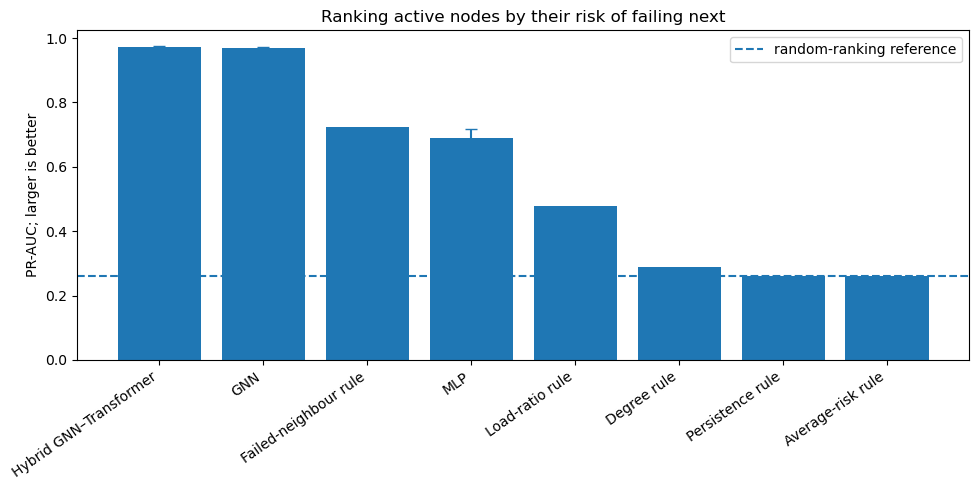

In [42]:
plot_table = comparison.sort_values("pr_auc", ascending=False).reset_index(drop=True)

figure, axis = plt.subplots(figsize=(10, 5))
positions = np.arange(len(plot_table))
axis.bar(positions, plot_table["pr_auc"])

for position, row in plot_table.iterrows():
    if row["type"] == "neural" and pd.notna(row.get("pr_auc_ci_lower", np.nan)):
        lower_error = max(float(row["pr_auc"] - row["pr_auc_ci_lower"]), 0.0)
        upper_error = max(float(row["pr_auc_ci_upper"] - row["pr_auc"]), 0.0)
        axis.errorbar(
            position,
            row["pr_auc"],
            yerr=[[lower_error], [upper_error]],
            fmt="none",
            capsize=4,
        )

axis.axhline(prevalence, linestyle="--", label="random-ranking reference")
axis.set_xticks(positions, plot_table["display_name"], rotation=35, ha="right")
axis.set_ylabel("PR-AUC; larger is better")
axis.set_title("Ranking active nodes by their risk of failing next")
axis.legend()
figure.tight_layout()
figure.savefig(FIGURE_DIR / "01_pr_auc_model_comparison.png", dpi=180)
plt.show()


In [43]:
selected_interval = model_metrics[selected_model]["bootstrap_95_ci"]["pr_auc"]
interval_width = float(selected_interval["upper"] - selected_interval["lower"])

display(Markdown(
    f"**Detailed reading.** {MODEL_LABELS[selected_model]} obtains test PR-AUC "
    f"**{selected_test_row['pr_auc']:.3f}**, compared with the random reference "
    f"**{prevalence:.3f}**. Its graph-bootstrap 95% interval is approximately "
    f"**[{selected_interval['lower']:.3f}, {selected_interval['upper']:.3f}]** "
    f"(width **{interval_width:.3f}**). The central score tells us the observed ranking "
    f"quality; the interval reminds us how much that score depends on which test graphs "
    f"happened to be sampled."
))


**Detailed reading.** Hybrid GNN–Transformer obtains test PR-AUC **0.971**, compared with the random reference **0.260**. Its graph-bootstrap 95% interval is approximately **[0.966, 0.975]** (width **0.010**). The central score tells us the observed ranking quality; the interval reminds us how much that score depends on which test graphs happened to be sampled.

## Precision recall curves Plot

A precision recall curve shows every possible alarm threshold.

- Moving to the right means catching more real failures: recall increases.
- Moving upward means a larger fraction of alarms is correct: precision increases.
- A curve that remains high while moving right is desirable.

There is no single “best point” for every application. A safety-critical operator may accept more false alarms to avoid missing a failure, while a low-budget inspection team may require higher precision.

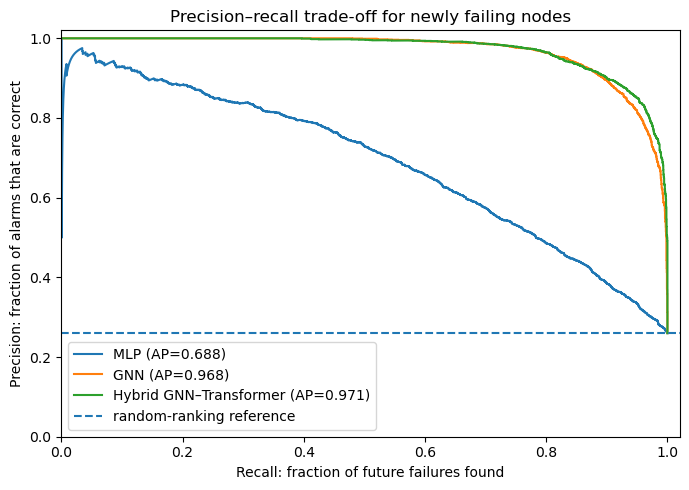

In [44]:
figure, axis = plt.subplots(figsize=(7, 5))

for model_name in MODEL_NAMES:
    saved = model_predictions[model_name]
    precision_curve, recall_curve, _ = precision_recall_curve(
        saved["active_new_target"],
        saved["active_node_score"],
    )
    axis.plot(
        recall_curve,
        precision_curve,
        label=f"{MODEL_LABELS[model_name]} (AP={model_metrics[model_name]['pr_auc']:.3f})",
    )

axis.axhline(prevalence, linestyle="--", label="random-ranking reference")
axis.set_xlabel("Recall: fraction of future failures found")
axis.set_ylabel("Precision: fraction of alarms that are correct")
axis.set_title("Precision–recall trade-off for newly failing nodes")
axis.set_xlim(0.0, 1.02)
axis.set_ylim(0.0, 1.02)
axis.legend()
figure.tight_layout()
figure.savefig(FIGURE_DIR / "02_precision_recall_curves.png", dpi=180)
plt.show()


## Alarm threshold choice Plot

The network outputs a continuous score between 0 and 1. The threshold converts that score into a yes/no alarm.

Think of a smoke detector:

- a very low threshold rings for a little steam, so it catches almost every fire but creates many false alarms;
- a very high threshold rings only for thick smoke, so alarms are cleaner but some fires are missed.

The threshold was selected on validation data by maximizing F1. A broad, flat top is safer than a needle-like peak because a tiny score change does not completely alter the decision.

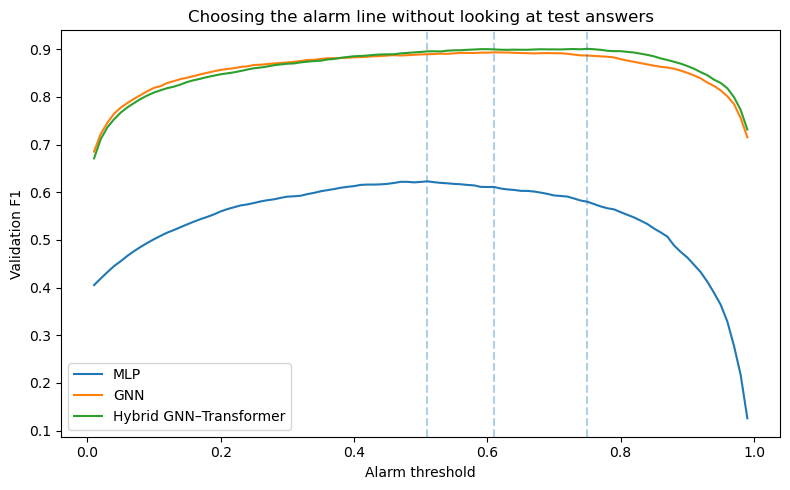

,model,selected_threshold,maximum_validation_f1,95_percent_peak_width
0,MLP,0.51,0.623,0.39
1,GNN,0.61,0.893,0.72
2,Hybrid GNN–Transformer,0.75,0.901,0.67


In [45]:
threshold_summary_rows = []
figure, axis = plt.subplots(figsize=(8, 5))

for model_name in MODEL_NAMES:
    table = threshold_tables[model_name]
    selected_threshold = float(model_metrics[model_name]["threshold"])
    maximum_f1 = float(table["f1"].max())
    near_best = table[table["f1"] >= 0.95 * maximum_f1]
    robust_width = float(near_best["threshold"].max() - near_best["threshold"].min())

    threshold_summary_rows.append(
        {
            "model": MODEL_LABELS[model_name],
            "selected_threshold": selected_threshold,
            "maximum_validation_f1": maximum_f1,
            "95_percent_peak_width": robust_width,
        }
    )

    axis.plot(table["threshold"], table["f1"], label=MODEL_LABELS[model_name])
    axis.axvline(selected_threshold, linestyle="--", alpha=0.35)

axis.set_xlabel("Alarm threshold")
axis.set_ylabel("Validation F1")
axis.set_title("Choosing the alarm line without looking at test answers")
axis.legend()
figure.tight_layout()
figure.savefig(FIGURE_DIR / "03_threshold_selection.png", dpi=180)
plt.show()

display(pd.DataFrame(threshold_summary_rows).round(3))


In [46]:
selected_threshold_row = next(
    row for row in threshold_summary_rows if row["model"] == MODEL_LABELS[selected_model]
)
shape_word = (
    "fairly broad"
    if selected_threshold_row["95_percent_peak_width"] >= 0.10
    else "rather narrow"
)

display(Markdown(
    f"For {MODEL_LABELS[selected_model]}, the selected threshold is "
    f"**{selected_threshold_row['selected_threshold']:.2f}**. The region retaining at "
    f"least 95% of the best validation F1 has width "
    f"**{selected_threshold_row['95_percent_peak_width']:.2f}**, which is {shape_word}. "
    f"A narrow region means that probability calibration and threshold monitoring become "
    f"more important when data conditions change."
))


For Hybrid GNN–Transformer, the selected threshold is **0.75**. The region retaining at least 95% of the best validation F1 has width **0.67**, which is fairly broad. A narrow region means that probability calibration and threshold monitoring become more important when data conditions change.

## Confusion Matrix of the four possible node level outcomes

For the validation selected model, every active test node falls into one of four boxes:

1. **True negative:** predicted safe and stayed active.
2. **False positive:** alarmed but stayed active.
3. **False negative:** predicted safe but failed. This is the dangerous miss.
4. **True positive:** alarmed and really failed.

Because safe nodes are common, the top-left box can be very large. That large number should not distract us from the smaller but operationally important failure boxes.

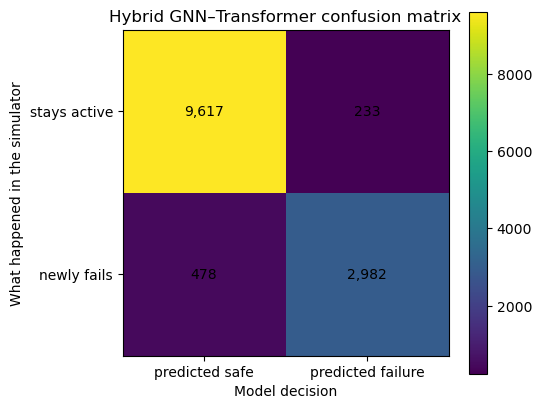

In [47]:
selected_saved = model_predictions[selected_model]
selected_threshold = float(model_metrics[selected_model]["threshold"])
selected_target = selected_saved["active_new_target"].astype(int)
selected_score = selected_saved["active_node_score"].astype(float)
selected_prediction = (selected_score >= selected_threshold).astype(int)

matrix = confusion_matrix(selected_target, selected_prediction, labels=[0, 1])
tn, fp, fn, tp = matrix.ravel()

figure, axis = plt.subplots(figsize=(5.5, 4.5))
image = axis.imshow(matrix)
for row in range(2):
    for column in range(2):
        axis.text(column, row, f"{matrix[row, column]:,}", ha="center", va="center")
axis.set_xticks([0, 1], ["predicted safe", "predicted failure"])
axis.set_yticks([0, 1], ["stays active", "newly fails"])
axis.set_xlabel("Model decision")
axis.set_ylabel("What happened in the simulator")
axis.set_title(f"{MODEL_LABELS[selected_model]} confusion matrix")
figure.colorbar(image, ax=axis)
figure.tight_layout()
figure.savefig(FIGURE_DIR / "04_selected_model_confusion_matrix.png", dpi=180)
plt.show()


In [48]:
precision_value = tp / max(tp + fp, 1)
recall_value = tp / max(tp + fn, 1)

miss_sentence = (
    "Missed failures are fewer than captured failures."
    if fn < tp
    else "The model misses at least as many failures as it captures, so the operating "
         "threshold would need careful reconsideration for a safety-focused use case."
)

display(Markdown(
    f"**Count-by-count interpretation.** The model correctly catches **{tp:,}** new "
    f"failures and misses **{fn:,}**. It also creates **{fp:,}** false alarms, while "
    f"correctly leaving **{tn:,}** active nodes without an alarm. This gives precision "
    f"**{precision_value:.3f}** and recall **{recall_value:.3f}** at the threshold chosen "
    f"on validation data. {miss_sentence}"
))


**Count-by-count interpretation.** The model correctly catches **2,982** new failures and misses **478**. It also creates **233** false alarms, while correctly leaving **9,617** active nodes without an alarm. This gives precision **0.928** and recall **0.862** at the threshold chosen on validation data. Missed failures are fewer than captured failures.

## Final cascade-size prediction results

The node head asks “which component fails next?” The graph head asks a broader question: “how much of the network will eventually be failed?”

In the scatter plot:

- each dot is one transition example;
- the horizontal coordinate is the true final failed fraction;
- the vertical coordinate is the prediction;
- the dashed diagonal is perfect prediction.

A point above the line is an overestimate. A point below the line is an underestimate. Not underestimating large cascades is especially important because those are the scenarios a resilience tool must not treat as harmless.

,model,graph_mae,graph_rmse
2,Hybrid GNN–Transformer,0.072,0.177
1,GNN,0.104,0.194
0,MLP,0.113,0.226


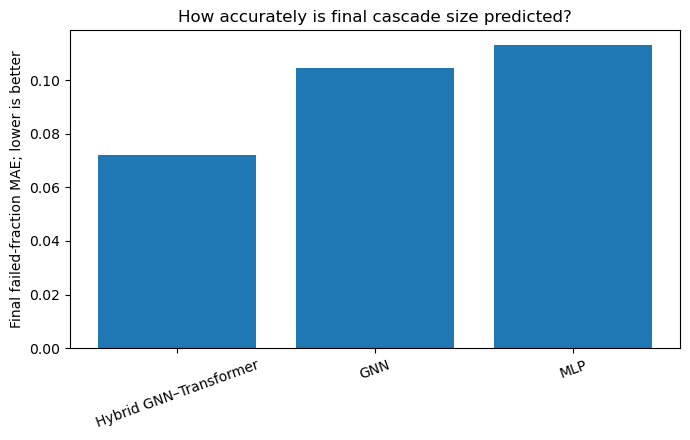

In [49]:
graph_rows = []
for model_name in MODEL_NAMES:
    graph_rows.append(
        {
            "model": MODEL_LABELS[model_name],
            "graph_mae": float(model_metrics[model_name]["graph_mae"]),
            "graph_rmse": float(model_metrics[model_name]["graph_rmse"]),
        }
    )
graph_table = pd.DataFrame(graph_rows).sort_values("graph_mae")
display(graph_table.round(3))

figure, axis = plt.subplots(figsize=(7, 4.5))
axis.bar(graph_table["model"], graph_table["graph_mae"])
axis.set_ylabel("Final failed-fraction MAE; lower is better")
axis.set_title("How accurately is final cascade size predicted?")
axis.tick_params(axis="x", rotation=20)
figure.tight_layout()
figure.savefig(FIGURE_DIR / "05_graph_mae_comparison.png", dpi=180)
plt.show()


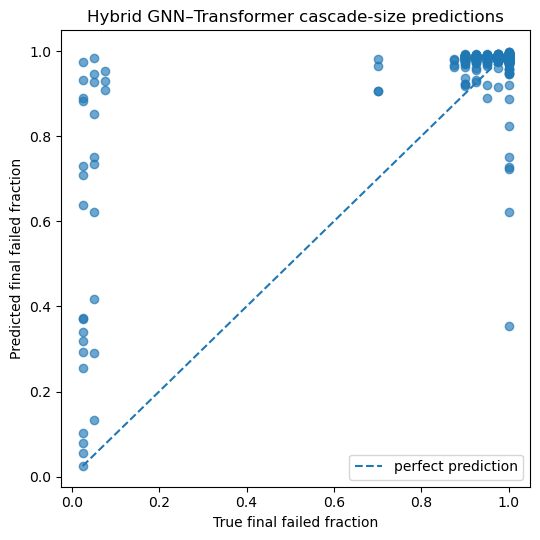

,severity_group,mean_true_cascade,mean_absolute_error,samples
0,group 1,0.662,0.206,109
1,group 2,0.951,0.033,108
2,group 3,0.987,0.031,108
3,group 4,1.000,0.018,108


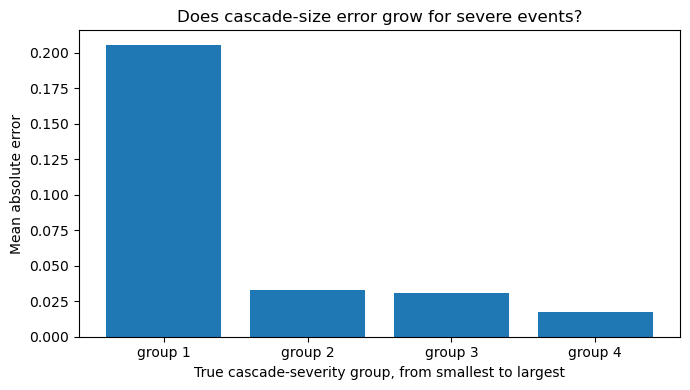

In [50]:
graph_target = selected_saved["graph_target"].astype(float)
graph_prediction = selected_saved["graph_pred"].astype(float)
absolute_error = np.abs(graph_prediction - graph_target)

figure, axis = plt.subplots(figsize=(5.5, 5.5))
axis.scatter(graph_target, graph_prediction, alpha=0.65)
lower = float(min(graph_target.min(), graph_prediction.min()))
upper = float(max(graph_target.max(), graph_prediction.max()))
axis.plot([lower, upper], [lower, upper], linestyle="--", label="perfect prediction")
axis.set_xlabel("True final failed fraction")
axis.set_ylabel("Predicted final failed fraction")
axis.set_title(f"{MODEL_LABELS[selected_model]} cascade-size predictions")
axis.legend()
figure.tight_layout()
figure.savefig(FIGURE_DIR / "06_selected_model_cascade_scatter.png", dpi=180)
plt.show()

cascade_frame = pd.DataFrame(
    {
        "true_cascade_fraction": graph_target,
        "absolute_error": absolute_error,
    }
)

number_of_bins = min(4, cascade_frame["true_cascade_fraction"].nunique())
if number_of_bins >= 2:
    cascade_frame["severity_group"] = pd.qcut(
        cascade_frame["true_cascade_fraction"].rank(method="first"),
        q=number_of_bins,
        labels=[f"group {index + 1}" for index in range(number_of_bins)],
    )
    severity_error = (
        cascade_frame.groupby("severity_group", observed=True, as_index=False)
        .agg(
            mean_true_cascade=("true_cascade_fraction", "mean"),
            mean_absolute_error=("absolute_error", "mean"),
            samples=("absolute_error", "size"),
        )
    )
    display(severity_error.round(3))

    figure, axis = plt.subplots(figsize=(7, 4))
    axis.bar(severity_error["severity_group"].astype(str), severity_error["mean_absolute_error"])
    axis.set_xlabel("True cascade-severity group, from smallest to largest")
    axis.set_ylabel("Mean absolute error")
    axis.set_title("Does cascade-size error grow for severe events?")
    figure.tight_layout()
    figure.savefig(FIGURE_DIR / "07_error_by_cascade_severity.png", dpi=180)
    plt.show()
else:
    severity_error = None
    print("Not enough distinct cascade sizes for a severity-group plot.")


In [51]:
mean_bias = float(np.mean(graph_prediction - graph_target))
selected_graph_mae = float(model_metrics[selected_model]["graph_mae"])

if mean_bias > 0.01:
    bias_message = "On average, the graph head overestimates cascade size."
elif mean_bias < -0.01:
    bias_message = "On average, the graph head underestimates cascade size."
else:
    bias_message = "The average signed bias is close to zero, although individual errors remain."

severity_message = ""
if severity_error is not None:
    first_error = float(severity_error.iloc[0]["mean_absolute_error"])
    last_error = float(severity_error.iloc[-1]["mean_absolute_error"])
    if last_error > first_error:
        severity_message = (
            f" Error is larger in the highest-severity group ({last_error:.3f}) than in "
            f"the lowest group ({first_error:.3f}), so severe cascades remain the harder cases."
        )
    else:
        severity_message = (
            f" Error is not larger in the highest-severity group in this test "
            f"({last_error:.3f} versus {first_error:.3f}). This is encouraging, but the "
            f"group sample counts still matter."
        )

display(Markdown(
    f"{MODEL_LABELS[selected_model]} has final cascade-fraction MAE "
    f"**{selected_graph_mae:.3f}**. That means its prediction differs from the true "
    f"failed fraction by about **{100 * selected_graph_mae:.1f} percentage points** on "
    f"average. The mean signed error is **{mean_bias:+.3f}**. {bias_message}{severity_message}"
))


Hybrid GNN–Transformer has final cascade-fraction MAE **0.072**. That means its prediction differs from the true failed fraction by about **7.2 percentage points** on average. The mean signed error is **+0.050**. On average, the graph head overestimates cascade size. Error is not larger in the highest-severity group in this test (0.018 versus 0.206). This is encouraging, but the group sample counts still matter.

## Next-step load prediction results

Load prediction is a secondary regression task. It encourages the shared representation to understand not only the binary failure label but also the continuous stress state of each node.

Lower MAE and RMSE are better. RMSE punishes occasional large errors more strongly than MAE, so a large gap between them suggests a few difficult load predictions.

,model,load_mae,load_rmse
2,Hybrid GNN–Transformer,0.125,0.256
1,GNN,0.146,0.255
0,MLP,0.440,0.670


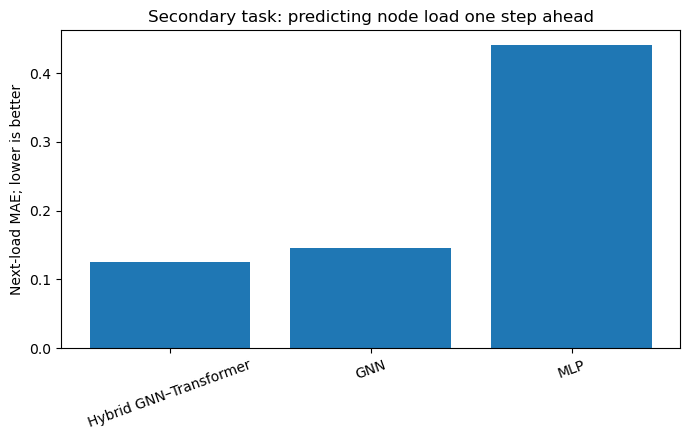

In [52]:
load_rows = []
for model_name in MODEL_NAMES:
    load_rows.append(
        {
            "model": MODEL_LABELS[model_name],
            "load_mae": float(model_metrics[model_name]["load_mae"]),
            "load_rmse": float(model_metrics[model_name]["load_rmse"]),
        }
    )
load_table = pd.DataFrame(load_rows).sort_values("load_mae")
display(load_table.round(3))

figure, axis = plt.subplots(figsize=(7, 4.5))
axis.bar(load_table["model"], load_table["load_mae"])
axis.set_ylabel("Next-load MAE; lower is better")
axis.set_title("Secondary task: predicting node load one step ahead")
axis.tick_params(axis="x", rotation=20)
figure.tight_layout()
figure.savefig(FIGURE_DIR / "08_load_mae_comparison.png", dpi=180)
plt.show()


In [53]:
best_load = load_table.iloc[0]
rmse_gap = float(best_load["load_rmse"] - best_load["load_mae"])

display(Markdown(
    f"The smallest next-load MAE belongs to **{best_load['model']}** at "
    f"**{best_load['load_mae']:.3f}**. Its RMSE is **{best_load['load_rmse']:.3f}**, "
    f"which is **{rmse_gap:.3f}** above MAE. This head is useful because it tests whether "
    f"the learned representation tracks the continuous redistribution process, but the "
    f"main project claim should still be based on new-failure prediction and cascade size."
))


The smallest next-load MAE belongs to **Hybrid GNN–Transformer** at **0.125**. Its RMSE is **0.256**, which is **0.131** above MAE. This head is useful because it tests whether the learned representation tracks the continuous redistribution process, but the main project claim should still be based on new-failure prediction and cascade size.

## Generalization across graph families and cascade mechanisms

An average score can hide a serious weakness. For example, a model may work well on random graphs and poorly on scale-free graphs, even if the overall number looks good.

The next plots therefore ask whether the ranking survives a change in:

- **graph family:** the shape of the network;
- **cascade regime:** the rule by which damage spreads.

A low subgroup score may indicate missing training coverage, a model limitation, or simply too few independent graphs. It is a warning flag, not a final diagnosis by itself.

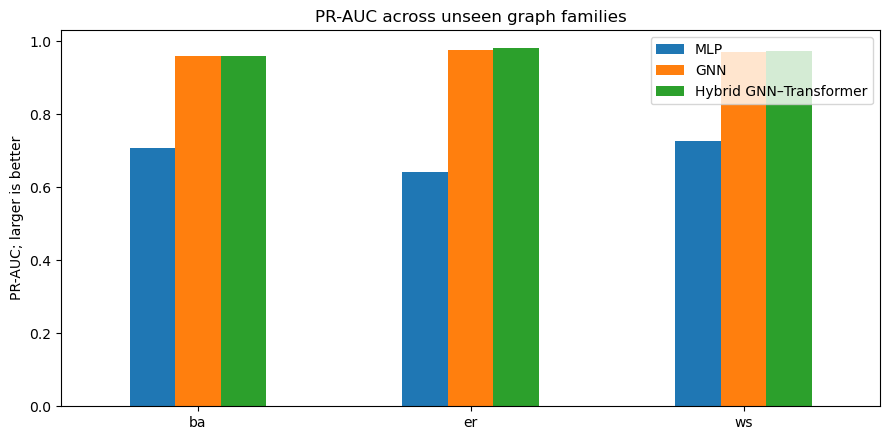

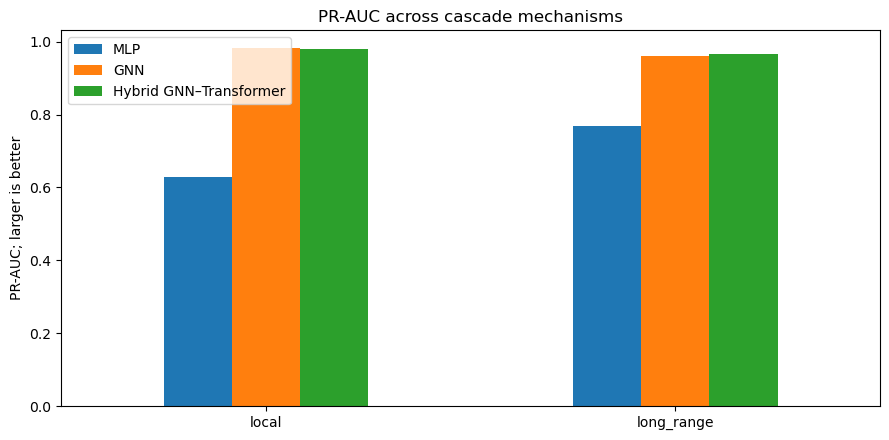

In [54]:
for grouping, title, filename in [
    ("by_family", "PR-AUC across unseen graph families", "09_pr_auc_by_family.png"),
    ("by_regime", "PR-AUC across cascade mechanisms", "10_pr_auc_by_regime.png"),
]:
    subset = grouped[grouped["grouping"] == grouping].copy()
    pivot = subset.pivot(index="group", columns="model", values="pr_auc")
    pivot = pivot[[name for name in MODEL_NAMES if name in pivot.columns]]
    pivot.columns = [MODEL_LABELS[name] for name in pivot.columns]

    figure, axis = plt.subplots(figsize=(9, 4.5))
    pivot.plot(kind="bar", ax=axis)
    axis.set_xlabel("")
    axis.set_ylabel("PR-AUC; larger is better")
    axis.set_title(title)
    axis.tick_params(axis="x", rotation=0)
    figure.tight_layout()
    figure.savefig(FIGURE_DIR / filename, dpi=180)
    plt.show()


In [55]:
subgroup_explanations = []
for model_name in MODEL_NAMES:
    model_groups = grouped[grouped["model"] == model_name].copy()
    strongest = model_groups.loc[model_groups["pr_auc"].idxmax()]
    weakest = model_groups.loc[model_groups["pr_auc"].idxmin()]
    spread = float(strongest["pr_auc"] - weakest["pr_auc"])

    subgroup_explanations.append(
        {
            "model": MODEL_LABELS[model_name],
            "strongest_condition": f"{strongest['grouping']} / {strongest['group']}",
            "strongest_pr_auc": strongest["pr_auc"],
            "weakest_condition": f"{weakest['grouping']} / {weakest['group']}",
            "weakest_pr_auc": weakest["pr_auc"],
            "spread": spread,
            "weakest_graphs": int(weakest["independent_graphs"]),
        }
    )

subgroup_table = pd.DataFrame(subgroup_explanations)
display(subgroup_table.round(3))

selected_subgroup = subgroup_table[subgroup_table["model"] == MODEL_LABELS[selected_model]].iloc[0]
display(Markdown(
    f"For {MODEL_LABELS[selected_model]}, the strongest listed condition is "
    f"**{selected_subgroup['strongest_condition']}** with PR-AUC "
    f"**{selected_subgroup['strongest_pr_auc']:.3f}**, while the weakest is "
    f"**{selected_subgroup['weakest_condition']}** with PR-AUC "
    f"**{selected_subgroup['weakest_pr_auc']:.3f}**. The spread is "
    f"**{selected_subgroup['spread']:.3f}**. The weakest result is based on "
    f"**{int(selected_subgroup['weakest_graphs'])} independent graphs**, which should be "
    f"checked before deciding whether the weakness is structural or only sampling noise."
))


,model,strongest_condition,strongest_pr_auc,weakest_condition,weakest_pr_auc,spread,weakest_graphs
0,MLP,by_regime / long_range,0.769,by_regime / local,0.630,0.139,68
1,GNN,by_regime / local,0.982,by_family / ba,0.958,0.024,46
2,Hybrid GNN–Transformer,by_regime / local,0.980,by_family / ba,0.959,0.021,46


For Hybrid GNN–Transformer, the strongest listed condition is **by_regime / local** with PR-AUC **0.980**, while the weakest is **by_family / ba** with PR-AUC **0.959**. The spread is **0.021**. The weakest result is based on **46 independent graphs**, which should be checked before deciding whether the weakness is structural or only sampling noise.

## Did explicit graph structure help?

This is the central architecture question of the DL project.

- The MLP sees a flattened description and must discover relationships indirectly.
- The GNN passes information along graph edges.
- The hybrid model combines local graph message passing with a broader attention mechanism.

We compare each graph-aware model with the MLP. A positive PR-AUC or F1 difference supports the value of graph structure. A negative graph-MAE difference is good because smaller error is better.

In [56]:
mlp_row = comparison[comparison["model"] == "mlp"].iloc[0]
architecture_rows = []

for model_name in ["gnn", "hybrid"]:
    row = comparison[comparison["model"] == model_name].iloc[0]
    architecture_rows.append(
        {
            "model": MODEL_LABELS[model_name],
            "PR-AUC minus MLP": float(row["pr_auc"] - mlp_row["pr_auc"]),
            "F1 minus MLP": float(row["f1"] - mlp_row["f1"]),
            "Graph MAE minus MLP": float(row["graph_mae"] - mlp_row["graph_mae"]),
            "Load MAE minus MLP": float(row["load_mae"] - mlp_row["load_mae"]),
        }
    )

architecture_table = pd.DataFrame(architecture_rows)
display(architecture_table.round(3))


,model,PR-AUC minus MLP,F1 minus MLP,Graph MAE minus MLP,Load MAE minus MLP
0,GNN,0.280,0.265,-0.009,-0.294
1,Hybrid GNN–Transformer,0.283,0.261,-0.041,-0.315


In [57]:
best_graph_aware = max(
    ["gnn", "hybrid"],
    key=lambda name: float(comparison.loc[comparison["model"] == name, "pr_auc"].iloc[0]),
)
best_graph_row = comparison[comparison["model"] == best_graph_aware].iloc[0]
pr_delta = float(best_graph_row["pr_auc"] - mlp_row["pr_auc"])

if pr_delta > 0.02:
    graph_message = (
        "The graph-aware architecture produces a meaningful ranking gain over the MLP in "
        "this experiment."
    )
elif pr_delta > 0:
    graph_message = (
        "The graph-aware architecture is slightly better, but the gain is small and should "
        "not be oversold without repeated seeds."
    )
else:
    graph_message = (
        "The graph-aware architecture does not beat the MLP on test PR-AUC in this run. "
        "That is an important result: using graph layers is not automatically beneficial."
    )

display(Markdown(
    f"The strongest graph-aware ranking is **{MODEL_LABELS[best_graph_aware]}**, whose "
    f"PR-AUC differs from the MLP by **{pr_delta:+.3f}**. {graph_message} The table also "
    f"shows whether any gain in node ranking comes with better or worse cascade-size and "
    f"load regression."
))


The strongest graph-aware ranking is **Hybrid GNN–Transformer**, whose PR-AUC differs from the MLP by **+0.283**. The graph-aware architecture produces a meaningful ranking gain over the MLP in this experiment. The table also shows whether any gain in node ranking comes with better or worse cascade-size and load regression.

## Training behaviour
### Did the models stop learning or start memorising?

Training loss measures how well a model fits examples it has seen. Validation loss measures how well it handles held out graphs during training.

- If both curves decrease together, learning is healthy.
- If training loss decreases while validation loss rises, the model is beginning to memorise.
- If both curves are still decreasing at the final epoch, more training may help.
- If the validation curve is flat or rising, simply adding epochs is unlikely to solve the problem.

This plot is supportive context. The final model comparison still comes from the graph disjoint test set.

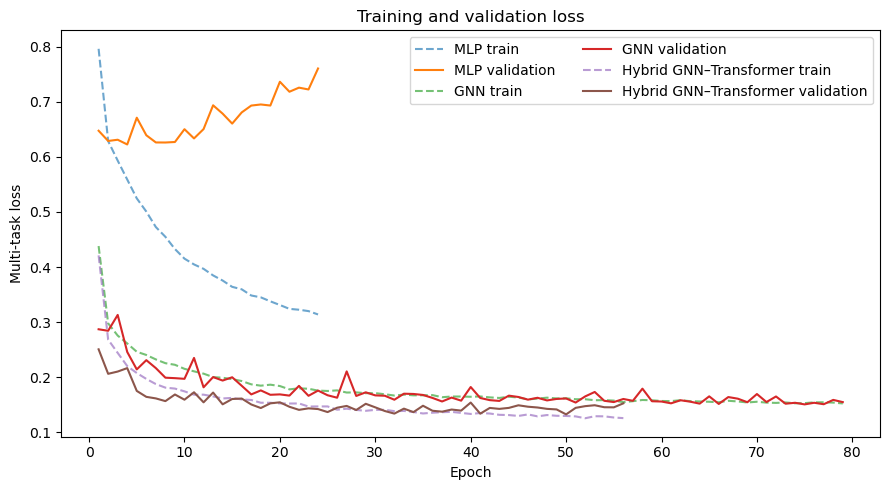

In [58]:
history_records = {}
figure, axis = plt.subplots(figsize=(9, 5))

for model_name in MODEL_NAMES:
    history_path = HISTORY_DIR / f"{model_name}.json"
    if not history_path.exists():
        continue

    history = json.loads(history_path.read_text(encoding="utf-8"))
    history_records[model_name] = history

    epochs = [record["epoch"] for record in history]
    training_loss = [record["train"]["loss"] for record in history]
    validation_loss = [record["val"]["loss"] for record in history]

    axis.plot(epochs, training_loss, linestyle="--", alpha=0.65, label=f"{MODEL_LABELS[model_name]} train")
    axis.plot(epochs, validation_loss, label=f"{MODEL_LABELS[model_name]} validation")

if history_records:
    axis.set_xlabel("Epoch")
    axis.set_ylabel("Multi-task loss")
    axis.set_title("Training and validation loss")
    axis.legend(ncol=2)
    figure.tight_layout()
    figure.savefig(FIGURE_DIR / "11_learning_curves.png", dpi=180)
    plt.show()
else:
    plt.close(figure)
    print("No training-history JSON files were found. The rest of the results remain valid.")


In [59]:
training_summary = []
for model_name, history in history_records.items():
    validation_losses = np.asarray([record["val"]["loss"] for record in history], dtype=float)
    training_losses = np.asarray([record["train"]["loss"] for record in history], dtype=float)
    epochs = np.asarray([record["epoch"] for record in history], dtype=int)

    best_index = int(np.argmin(validation_losses))
    training_summary.append(
        {
            "model": MODEL_LABELS[model_name],
            "epochs_run": int(len(history)),
            "best_validation_epoch": int(epochs[best_index]),
            "best_validation_loss": float(validation_losses[best_index]),
            "final_validation_loss": float(validation_losses[-1]),
            "final_train_loss": float(training_losses[-1]),
            "final_generalisation_gap": float(validation_losses[-1] - training_losses[-1]),
        }
    )

if training_summary:
    training_table = pd.DataFrame(training_summary)
    display(training_table.round(4))

    selected_history = training_table[training_table["model"] == MODEL_LABELS[selected_model]].iloc[0]
    last_is_best = selected_history["best_validation_epoch"] == training_table.loc[
        training_table["model"] == MODEL_LABELS[selected_model], "epochs_run"
    ].iloc[0]

    if selected_history["final_validation_loss"] > selected_history["best_validation_loss"] * 1.02:
        diagnosis = (
            "Its final validation loss is above its best value, so extending training without "
            "stronger regularisation would more likely increase overfitting than improve it."
        )
    elif last_is_best:
        diagnosis = (
            "Its best validation value occurs at the end of the recorded run, so a modest "
            "epoch extension could be tested, but only with early stopping and a fixed test set."
        )
    else:
        diagnosis = (
            "Its validation curve is close to its best value, so more epochs are not an obvious "
            "priority compared with more data or hyperparameter checks."
        )

    display(Markdown(
        f"For {MODEL_LABELS[selected_model]}, the best validation epoch is "
        f"**{int(selected_history['best_validation_epoch'])}**, while the final "
        f"train–validation gap is **{selected_history['final_generalisation_gap']:+.4f}**. "
        f"{diagnosis}"
    ))


,model,epochs_run,best_validation_epoch,best_validation_loss,final_validation_loss,final_train_loss,final_generalisation_gap
0,MLP,24,4,0.6226,0.7605,0.3139,0.4466
1,GNN,79,75,0.1506,0.1547,0.1523,0.0024
2,Hybrid GNN–Transformer,56,50,0.1324,0.1525,0.1256,0.0269


For Hybrid GNN–Transformer, the best validation epoch is **50**, while the final train–validation gap is **+0.0269**. Its final validation loss is above its best value, so extending training without stronger regularisation would more likely increase overfitting than improve it.

## Qualitative graph example

Numbers tell us whether a model works on average. A graph picture helps us see **where** it places risk on one example.

The code selects a test transition containing new failures, loads the validation-selected model, and colours active nodes by predicted probability. Already failed nodes are drawn separately. Red outlines mark nodes that really fail next.

This picture is an explanation aid, not an additional metric. One attractive example can never replace the full test set.

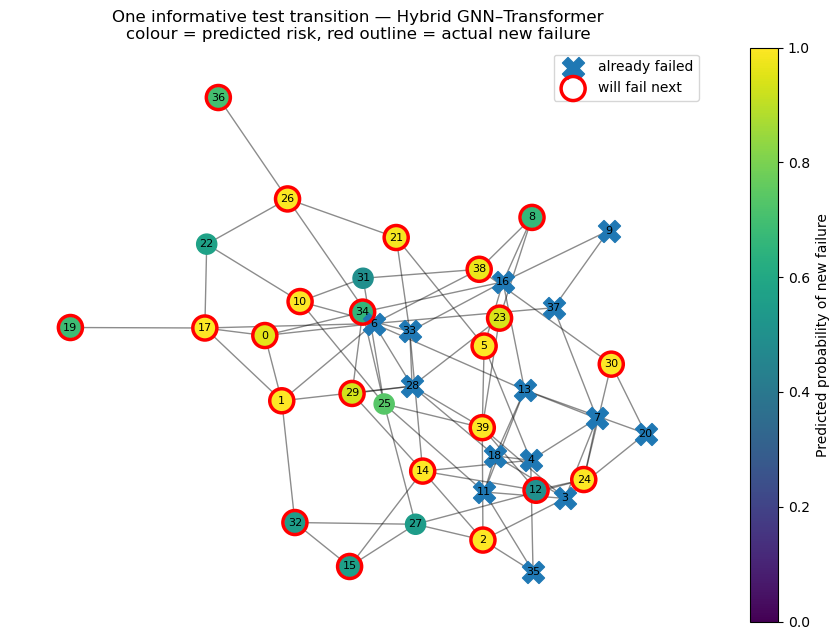

,node,currently_failed,will_fail_next,predicted_probability
2,2,False,True,1.0
4,4,True,False,1.0
35,35,True,False,1.0
7,7,True,False,1.0
3,3,True,False,1.0
14,14,False,True,1.0
6,6,True,False,1.0
20,20,True,False,1.0
13,13,True,False,1.0
11,11,True,False,1.0


This transition contains **22** newly failing nodes. Among the ten highest-risk nodes, **2** are true new failures. The visual pattern can reveal whether risk is concentrated around an already damaged area or spread across the graph, but the quantitative conclusions still come from all test graphs.

In [ ]:
try:
    import networkx as nx
    import torch
    from dl_models import build_model

    metadata = json.loads((DATA_DIR / "metadata.json").read_text(encoding="utf-8"))
    test_samples = torch.load(DATA_DIR / "test.pt", map_location="cpu", weights_only=False)

    # Pick an informative example for visualisation only: the transition with most new failures.
    new_failure_counts = []
    for sample in test_samples:
        current_failed = sample["x"][:, metadata["feature_names"].index("failed")] > 0.5
        next_failed = sample["y_node"] > 0.5
        new_failure_counts.append(int((next_failed & ~current_failed).sum()))

    sample_index = int(np.argmax(new_failure_counts))
    # sample_index = int(10)
    sample = test_samples[sample_index]
    number_of_nodes = int(sample["num_nodes"])

    checkpoint = torch.load(
        ROOT / "artifacts" / "checkpoints" / f"{selected_model}.pt",
        map_location="cpu",
        weights_only=False,
    )
    model = build_model(selected_model, metadata, config)
    model.load_state_dict(checkpoint["model_state"])
    model.eval()

    single_batch = {
        "x": sample["x"].unsqueeze(0),
        "adj": sample["adj"].unsqueeze(0),
        "lap_pe": sample["lap_pe"].unsqueeze(0),
        "dist": sample["dist"].unsqueeze(0),
        "mask": torch.ones(1, number_of_nodes, dtype=torch.bool),
    }

    with torch.no_grad():
        output = model(single_batch)

    probabilities = torch.sigmoid(output["node_logits"])[0].cpu().numpy()
    failed_index = metadata["feature_names"].index("failed")
    current_failed = sample["x"][:, failed_index].cpu().numpy() > 0.5
    next_failed = sample["y_node"].cpu().numpy() > 0.5
    newly_failed = next_failed & ~current_failed

    graph = nx.from_numpy_array(sample["adj"].cpu().numpy())
    positions = nx.spring_layout(graph, seed=int(config.get("seed", 42)))
    active_nodes = np.flatnonzero(~current_failed).tolist()
    failed_nodes = np.flatnonzero(current_failed).tolist()
    new_nodes = np.flatnonzero(newly_failed).tolist()

    figure, axis = plt.subplots(figsize=(9, 6.5))
    nx.draw_networkx_edges(graph, positions, ax=axis, alpha=0.45)

    active_artist = nx.draw_networkx_nodes(
        graph,
        positions,
        nodelist=active_nodes,
        node_color=probabilities[active_nodes],
        cmap="viridis",
        vmin=0,
        vmax=1,
        node_size=210,
        ax=axis,
    )

    if failed_nodes:
        nx.draw_networkx_nodes(
            graph,
            positions,
            nodelist=failed_nodes,
            node_shape="X",
            node_size=250,
            ax=axis,
            label="already failed",
        )

    if new_nodes:
        nx.draw_networkx_nodes(
            graph,
            positions,
            nodelist=new_nodes,
            node_color="none",
            edgecolors="red",
            linewidths=2.5,
            node_size=300,
            ax=axis,
            label="will fail next",
        )

    nx.draw_networkx_labels(graph, positions, font_size=8, ax=axis)
    figure.colorbar(active_artist, ax=axis, label="Predicted probability of new failure")
    axis.set_title(
        f"One informative test transition — {MODEL_LABELS[selected_model]}\n"
        "colour = predicted risk, red outline = actual new failure"
    )
    axis.axis("off")
    axis.legend()
    figure.tight_layout()
    figure.savefig(FIGURE_DIR / "12_qualitative_graph_example.png", dpi=180)
    plt.show()

    qualitative_table = pd.DataFrame(
        {
            "node": np.arange(number_of_nodes),
            "currently_failed": current_failed,
            "will_fail_next": newly_failed,
            "predicted_probability": probabilities,
        }
    ).sort_values("predicted_probability", ascending=False)
    display(qualitative_table.head(10).round(3))

    caught_in_top_10 = int(qualitative_table.head(10)["will_fail_next"].sum())
    total_new = int(newly_failed.sum())
    display(Markdown(
        f"This transition contains **{total_new}** newly failing nodes. Among the ten "
        f"highest-risk nodes, **{caught_in_top_10}** are true new failures. The visual pattern "
        f"can reveal whether risk is concentrated around an already damaged area or spread "
        f"across the graph, but the quantitative conclusions still come from all test graphs."
    ))

except Exception as error:
    display(Markdown(
        "The optional network visualisation could not be produced in this environment. "
        "The saved evaluation results above are unaffected. Details: " + str(error)
    ))


## Final scientific interpretation

### What a positive result means

If a neural model has PR-AUC clearly above prevalence and above sensible heuristics, then it has learned more than the class frequency. If a GNN or hybrid also improves over the MLP, the graph connections contain useful predictive information that a flat representation uses less effectively.

### What it does not mean

It does not prove performance on a real power grid, fibre network, road system, or unseen city. The simulator defines the physics of the current experiment. Real deployment would require real network data, domain-specific cascade rules, repeated random seeds, stronger out-of-distribution tests, and uncertainty that includes data and model variation.

In [61]:
selected_row = comparison[comparison["model"] == selected_model].iloc[0]
heuristic_gap = float(selected_row["pr_auc"] - best_heuristic["pr_auc"])
mlp_gap = float(selected_row["pr_auc"] - mlp_row["pr_auc"])

claim_lines = [
    "# Final Deep Learning result summary",
    "",
    f"- Validation-selected architecture: **{MODEL_LABELS[selected_model]}**.",
    f"- Test new-failure PR-AUC: **{selected_row['pr_auc']:.3f}** versus prevalence **{prevalence:.3f}**.",
    f"- Difference from the strongest heuristic: **{heuristic_gap:+.3f}** PR-AUC.",
    f"- Difference from the MLP: **{mlp_gap:+.3f}** PR-AUC.",
    f"- Node-level precision / recall / F1: **{selected_row['precision']:.3f} / {selected_row['recall']:.3f} / {selected_row['f1']:.3f}**.",
    f"- Final cascade-fraction MAE: **{selected_row['graph_mae']:.3f}**.",
    f"- Next-load MAE: **{selected_row['load_mae']:.3f}**.",
    "",
    "**Defensible conclusion:** the pipeline can learn and evaluate next-step cascade risk on graph-disjoint synthetic networks. The strength of the architecture claim depends on the observed MLP–graph-model gap and its stability across graph families, regimes, bootstrap intervals, and repeated seeds.",
    "",
    "**Main limitation:** this remains a controlled synthetic experiment, not validation for a real critical infrastructure system.",
]

summary_text = "\n".join(claim_lines)
summary_path = RESULTS_DIR / "DL_RESULTS_SUMMARY.md"
summary_path.write_text(summary_text, encoding="utf-8")

display(Markdown(summary_text))
print("Saved summary to:", summary_path)


# Final Deep Learning result summary

- Validation-selected architecture: **Hybrid GNN–Transformer**.
- Test new-failure PR-AUC: **0.971** versus prevalence **0.260**.
- Difference from the strongest heuristic: **+0.249** PR-AUC.
- Difference from the MLP: **+0.283** PR-AUC.
- Node-level precision / recall / F1: **0.928 / 0.862 / 0.893**.
- Final cascade-fraction MAE: **0.072**.
- Next-load MAE: **0.125**.

**Defensible conclusion:** the pipeline can learn and evaluate next-step cascade risk on graph-disjoint synthetic networks. The strength of the architecture claim depends on the observed MLP–graph-model gap and its stability across graph families, regimes, bootstrap intervals, and repeated seeds.

**Main limitation:** this remains a controlled synthetic experiment, not validation for a real critical infrastructure system.

Saved summary to: /home/riccorte/CIRCLES/DL/DL_project/artifacts/results/exam/DL_RESULTS_SUMMARY.md
